In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading the dataset

In [2]:
import pandas as pd

df = pd.read_csv("../data/shopping_trends.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


## Phase 1: Exploring the data

In [3]:
df.shape

(3900, 19)

In [4]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [6]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [7]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Venmo,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Venmo,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,PayPal,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


In [8]:
df.describe(include='object')

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Preferred Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Credit Card,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,696,675,2223,2223,677,584


## Phase 1: Dataset Overview

### Dataset Summary
Total number of rows: 3900
Total number of columns: 19
Numeric columns: 5
Categorical columns: 14
Missing values:None (every column has 3,900 non-null values)

| Feature            | Observation                                       |
| ------------------ | ------------------------------------------------- |
| Age                | Ranges from **18 to 70 years**, average **44.07** |
| Purchase Amount    | Ranges from **$20  to $100**, average **$59.76**   |
| Review Rating      | Ranges from **2.5 to 5.0**, average **3.75**      |
| Previous Purchases | Ranges from **1 to 50**, average **25.35**        |

### Key Observations

- Customers range from 18 to 70 years old.
- The average purchase amount is approximately $59.76.
- Review ratings range from 2.5 to 5.0.
- Customers have between 1 and 50 previous purchases.
- The dataset appears clean with no missing values.

## Phase 2: Data Quality Checks

In [9]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate records: {duplicates}")

Number of duplicate records: 0


### Duplicate Records

- The dataset contains 0 duplicate records.
- Based on the result, duplicate removal is not required.

### Check Unique Values

In [10]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [11]:
df['Category'].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

In [12]:
df['Season'].unique()

array(['Winter', 'Spring', 'Summer', 'Fall'], dtype=object)

In [13]:
df['Payment Method'].unique()

array(['Credit Card', 'Bank Transfer', 'Cash', 'PayPal', 'Venmo',
       'Debit Card'], dtype=object)

In [14]:
df['Shipping Type'].unique()

array(['Express', 'Free Shipping', 'Next Day Air', 'Standard',
       '2-Day Shipping', 'Store Pickup'], dtype=object)

In [15]:
# Count Unique Values in each column
df.nunique()

Customer ID                 3900
Age                           53
Gender                         2
Item Purchased                25
Category                       4
Purchase Amount (USD)         81
Location                      50
Size                           4
Color                         25
Season                         4
Review Rating                 26
Subscription Status            2
Payment Method                 6
Shipping Type                  6
Discount Applied               2
Promo Code Used                2
Previous Purchases            50
Preferred Payment Method       6
Frequency of Purchases         7
dtype: int64

In [16]:
#Random Sample Check
df.sample(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
3100,3101,50,Female,Hat,Accessories,85,Vermont,L,Purple,Winter,3.9,No,Venmo,Express,No,No,3,Bank Transfer,Weekly
319,320,47,Male,Shorts,Clothing,74,Maine,XL,White,Spring,2.6,Yes,Venmo,Standard,Yes,Yes,1,Cash,Every 3 Months
1962,1963,40,Male,Hat,Accessories,45,Iowa,M,Silver,Fall,4.4,No,Debit Card,Standard,No,No,20,PayPal,Fortnightly
3120,3121,46,Female,Shirt,Clothing,76,Louisiana,M,Magenta,Fall,4.0,No,Venmo,Store Pickup,No,No,32,Debit Card,Fortnightly
634,635,36,Male,Sneakers,Footwear,60,Ohio,M,Teal,Summer,3.9,Yes,Bank Transfer,Standard,Yes,Yes,46,PayPal,Weekly
343,344,27,Male,Sandals,Footwear,39,Nebraska,M,Purple,Summer,4.4,Yes,Cash,Next Day Air,Yes,Yes,26,Venmo,Monthly
16,17,25,Male,Sunglasses,Accessories,36,Alabama,S,Gray,Spring,4.1,Yes,Venmo,Next Day Air,Yes,Yes,44,Debit Card,Bi-Weekly
2968,2969,26,Female,Sweater,Clothing,48,South Carolina,S,Gray,Fall,4.9,No,Cash,Express,No,No,25,Cash,Every 3 Months
2890,2891,39,Female,Jeans,Clothing,55,North Dakota,M,Violet,Winter,3.7,No,PayPal,Free Shipping,No,No,23,Credit Card,Monthly
1406,1407,32,Male,Shirt,Clothing,46,Washington,L,Turquoise,Spring,3.6,No,Venmo,Express,Yes,Yes,15,Debit Card,Monthly


## Phase 2: Quality Checks Overview

### Data Quality Assessment

- Duplicate records: 0
- Missing values: 0
- Number of unique product categories: 4
- Number of payment methods: 6
- Number of shipping type: 6
- Dataset quality assessment:Done

## Feature Analysis

In [17]:
# List Data Types
df.dtypes

Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Review Rating               float64
Subscription Status          object
Payment Method               object
Shipping Type                object
Discount Applied             object
Promo Code Used              object
Previous Purchases            int64
Preferred Payment Method     object
Frequency of Purchases       object
dtype: object

In [18]:
# Count Numeric and Categorical Columns

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numeric Columns:
Index(['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating',
       'Previous Purchases'],
      dtype='object')

Categorical Columns:
Index(['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color',
       'Season', 'Subscription Status', 'Payment Method', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')


In [19]:
# Create a Feature Summary Table

feature_summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

feature_summary

,Column Name,Data Type,Missing Values,Unique Values
0,Customer ID,int64,0,3900
1,Age,int64,0,53
2,Gender,object,0,2
3,Item Purchased,object,0,25
4,Category,object,0,4
5,Purchase Amount (USD),int64,0,81
6,Location,object,0,50
7,Size,object,0,4
8,Color,object,0,25
9,Season,object,0,4


In [20]:
feature_summary.to_csv("../data/feature_summary.csv", index=False)

## Business Understanding

### Customer Information
- Customer ID
- Age
- Gender
- Location

### Product Information
- Item Purchased
- Category
- Size
- Color

### Transaction Information
- Purchase Amount (USD)
- Payment Method
- Preferred Payment Method
- Shipping Type
- Discount Applied
- Promo Code Used

### Customer Behavior
- Previous Purchases
- Frequency of Purchases
- Subscription Status

### Seasonal Information
- Season

### Customer Experience
- Review Rating

## Phase 3 Summary

### Key Findings

- Total numeric columns: 5
- Total categorical columns: 14
- Dataset contains customer, product, and transaction information.
- No missing values were observed.
- The dataset is suitable for exploratory data analysis.

# Phase 4: Exploratory Data Analysis (EDA)

## Task 1: Customer Age Distribution Analysis

## Business Question

What is the age distribution of customers, and which age groups represent the largest customer segment?

## Objective

Analyze the age distribution of customers to identify the primary customer demographic.

In [21]:
# Statistics
print("Minimum Age:", df["Age"].min())
print("Maximum Age:", df["Age"].max())
print("Average Age:", round(df["Age"].mean(),2))
print("Median Age:", df["Age"].median())

Minimum Age: 18
Maximum Age: 70
Average Age: 44.07
Median Age: 44.0


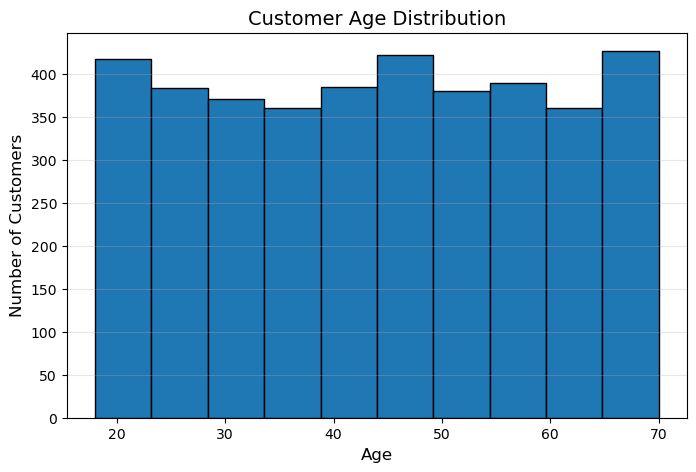

In [22]:

# Visualization: Histogram
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10, edgecolor="black")

plt.title("Customer Age Distribution", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis='y', alpha=0.3)

plt.show()

In [23]:
age_groups = [18,25,35,45,55,65,75]

age_labels = [
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65-74"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_groups,
    labels=age_labels,
    right=False
)

df["Age Group"].value_counts().sort_index()

Age Group
18-24    486
25-34    755
35-44    729
45-54    752
55-64    751
65-74    427
Name: count, dtype: int64

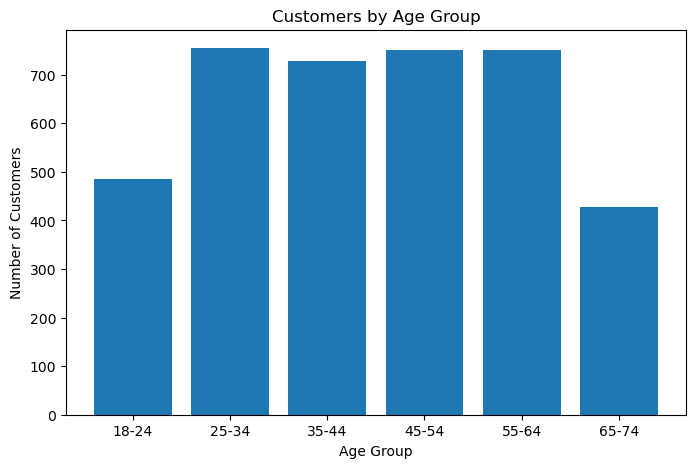

In [24]:
age_counts = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(age_counts.index.astype(str), age_counts.values)

plt.title("Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

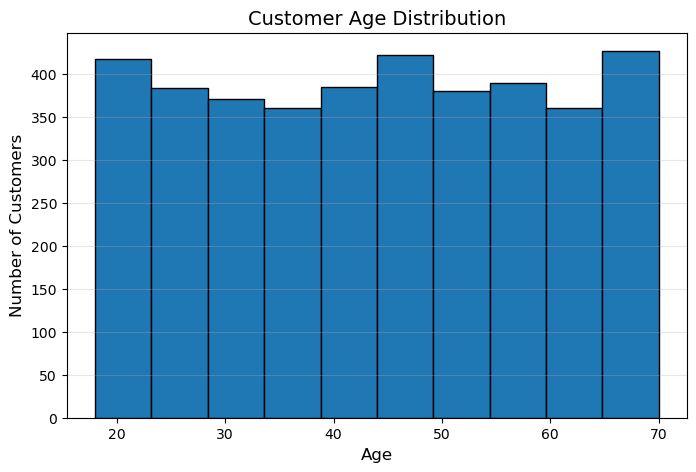

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10, edgecolor="black")

plt.title("Customer Age Distribution", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.savefig("../images/customer_age_distribution.png", dpi=300)

plt.show()

## Observations

- Customers range from 18 to 70 years.
- The average customer age is 44 years.
- The largest customer age group is 25 - 34.
- The smallest customer age group is 65 - 74.

## Business Insights

- Customers aged **25–34** represent the largest customer age group.
- Marketing campaigns should primarily target customers between **25 and 34 years**, while maintaining engagement strategies for other age groups.
- Personalized product recommendations can be developed for different age groups to improve customer engagement.
- Special promotions can be designed to increase engagement among customers aged **65–74**, the smallest customer age group.

## Conclusion

The age distribution provides valuable insight into the retailer's customer demographics and helps identify the primary target audience.

# Task 2: Purchase Amount Distribution Analysis

## Business Question

How are customer purchase amounts distributed, and what spending patterns can be identified?

## Business Objective

Analyze customer purchase amounts to understand customer spending behavior and identify purchasing trends.

In [26]:
purchase = df["Purchase Amount (USD)"]

print("Minimum Purchase Amount:", purchase.min())
print("Maximum Purchase Amount:", purchase.max())
print("Average Purchase Amount:", round(purchase.mean(), 2))
print("Median Purchase Amount:", purchase.median())
print("Standard Deviation:", round(purchase.std(), 2))

Minimum Purchase Amount: 20
Maximum Purchase Amount: 100
Average Purchase Amount: 59.76
Median Purchase Amount: 60.0
Standard Deviation: 23.69


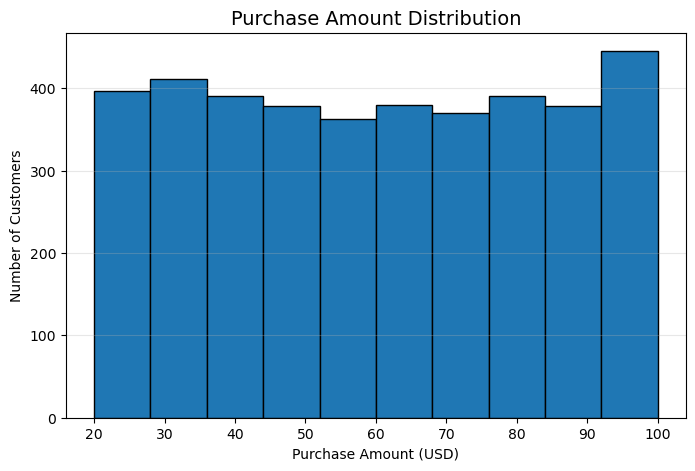

In [27]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Purchase Amount (USD)"],
    bins=10,
    edgecolor="black"
)

plt.title("Purchase Amount Distribution", fontsize=14)
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.3)

plt.show()

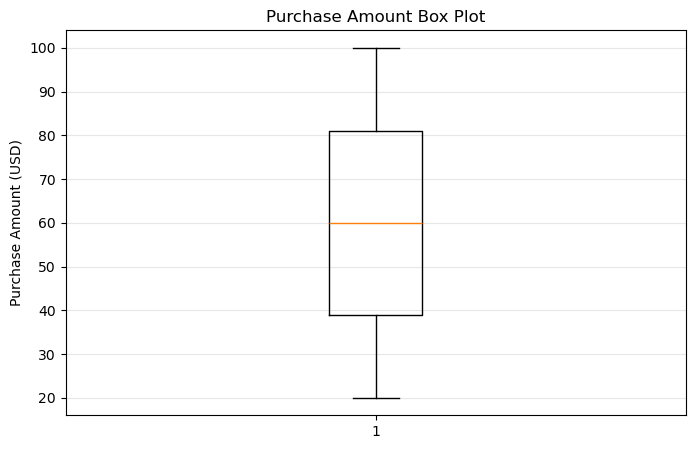

In [28]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Purchase Amount (USD)"])

plt.title("Purchase Amount Box Plot")

plt.ylabel("Purchase Amount (USD)")

plt.grid(axis="y", alpha=0.3)

plt.show()

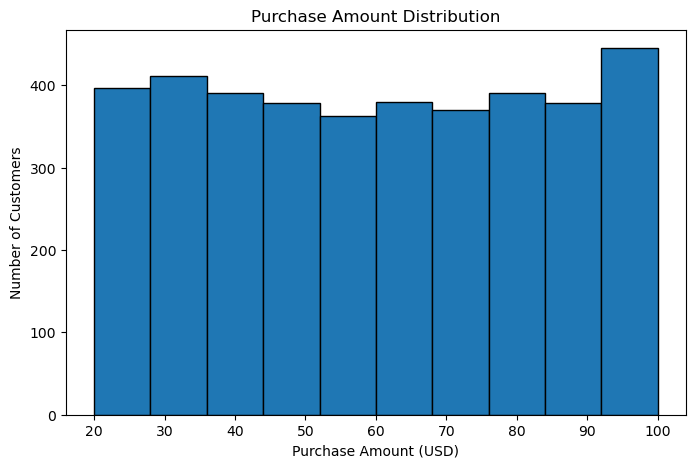

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Purchase Amount (USD)"],
    bins=10,
    edgecolor="black"
)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Number of Customers")

plt.savefig("../images/purchase_amount_distribution.png", dpi=300)

plt.show()

## Observations

- Minimum purchase amount: **\$20**
- Maximum purchase amount: **\$100**
- Average purchase amount: **\$59.76**
- Median purchase amount: **\$60.00**
- The purchase amounts are fairly evenly distributed across the range of **\$20** to **\$100**, with no strong concentration in any particular spending range.
- No significant outliers were observed in the purchase amounts.

## Business Insights

- Customer purchase amounts are distributed relatively evenly across the observed spending range.
- The average purchase amount of approximately **$60** provides an estimate of typical customer spending.
- The retailer can use customer spending behavior to design pricing and promotional strategies.
- Since no significant outliers were observed, there is no evidence of unusually extreme purchase amounts in this dataset.

## Conclusion

The purchase amount distribution provides insight into customer spending patterns and supports business decisions related to pricing, promotions, and customer segmentation.

# Task 10: Customer Gender Distribution Analysis

## Business Question

How is the customer base distributed by gender, and is customer representation balanced across genders?

## Business Objective

Analyze the gender distribution of customers to understand the composition of the customer base and identify whether one gender is more represented than the other.

In [30]:
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Male      2652
Female    1248
Name: count, dtype: int64

In [31]:
gender_percentage = df["Gender"].value_counts(normalize=True) * 100

gender_percentage.round(2)

Gender
Male      68.0
Female    32.0
Name: proportion, dtype: float64

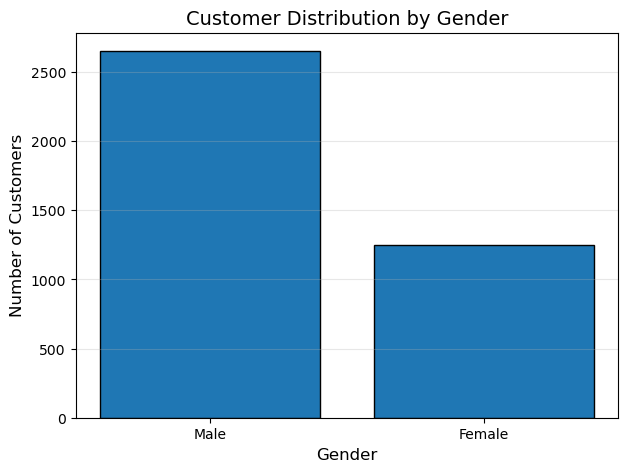

In [32]:
plt.figure(figsize=(7,5))

plt.bar(
    gender_counts.index,
    gender_counts.values,
    edgecolor="black"
)

plt.title("Customer Distribution by Gender", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.show()

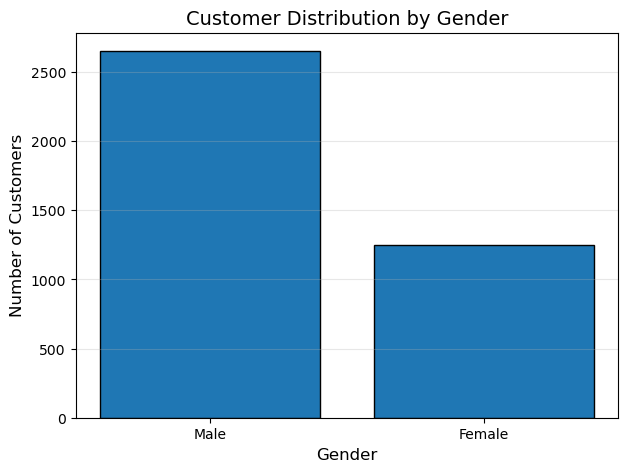

In [33]:
plt.figure(figsize=(7,5))

plt.bar(
    gender_counts.index,
    gender_counts.values,
    edgecolor="black"
)

plt.title("Customer Distribution by Gender", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.savefig("../images/customer_gender_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## Observations

- The dataset contains 2652 male customers and 1248 female customers.
- Male customers represent approximately 68% of the customer base.
- Female customers represent approximately 32% of the customer base.
- Male customers have a slightly higher representation in the customer base than female customers.

## Business Insights

- A balanced gender distribution suggests that the retailer serves a diverse customer base.
- Gender-based analysis can be combined with purchase behavior to identify potential differences in shopping preferences.
- Marketing strategies can be further evaluated using gender together with product categories, purchase amounts, and customer behavior.

## Conclusion

Understanding the gender distribution of customers provides insight into the composition of the customer base and can support further analysis of differences in purchasing behavior and product preferences.